# Imports

In [1]:
from pySVA.sva_core import *
from pySVA.sva_calc import *

In [2]:
import pandas as pd

In [3]:
from pySVA.sva_helpers import *

In [4]:
import dfm_tools as dfmt
import numpy as np
import xarray as xr

In [5]:
import pandas as pd

# Data description

In [6]:
# data_description = {
#     "nfaces": "mesh2d_nFaces",
#     "depth": "mesh2d_nLayers",
#     "time" : "time"
# }

data_description = {
    "flow_area": "mesh2d_au",
    "volume": "mesh2d_vol1",
    "velx" : "mesh2d_ucx",
    "vely" : "mesh2d_ucy",
    "velz" : "mesh2d_ucz",
    "viscosity" : "mesh2d_vicwwu",
    "tracer" : "mesh2d_sa1",
    "depth": "mesh2d_flowelem_zcc",
    "interfaces": "mesh2d_flowelem_zw"
}

In [7]:
import numpy as np

# Set up dask cluster

In [8]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

In [9]:
n_cores = 16 #96
n_processes = 16
n_workers = n_cores/n_processes
mem_lim = str(336) + 'GB' #str(336)+'GB' # str(int(np.floor(336/(n_workers))))+'GB' # 336 for genoa # 224 for rome #n_cores*

In [10]:
cluster = SLURMCluster(name='dask-cluster',
                       cores=n_cores,
                       memory=mem_lim,
                       interface='ib0',
                       queue='genoa',
                       walltime='01:00:00',
                       asynchronous=0)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34737 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: tcp://172.22.63.192:38395
INFO:distributed.scheduler:  dashboard at:  http://172.22.63.192:34737/status
INFO:distributed.scheduler:Registering Worker plugin shuffle


In [11]:
print(cluster.job_script())

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p genoa
#SBATCH -n 1
#SBATCH --cpus-per-task=16
#SBATCH --mem=313G
#SBATCH -t 01:00:00

/home/mgeraeds/.conda/envs/dfm_geo_py/bin/python -m distributed.cli.dask_worker tcp://172.22.63.192:38395 --name dummy-name --nthreads 4 --memory-limit 78.23GiB --nworkers 4 --nanny --death-timeout 60 --interface ib0



In [12]:
cluster.scale(1)

In [13]:
client = Client(cluster)

INFO:distributed.scheduler:Receive client connection: Client-5ae353a6-1f4c-11ef-a494-00001029fe80
INFO:distributed.core:Starting established connection to tcp://172.22.63.192:47754
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.58.181:38001', name: dask-cluster-0-2, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.58.181:38001
INFO:distributed.core:Starting established connection to tcp://172.22.58.181:44306
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.58.181:36661', name: dask-cluster-0-0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.58.181:36661
INFO:distributed.core:Starting established connection to tcp://172.22.58.181:44294
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.58.181:36719', name: dask-cluster-0-3, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting 

In [14]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.22.63.192:34737/status,
Dashboard: http://172.22.63.192:34737/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.22.63.192:38395,Workers: 0
Dashboard: http://172.22.63.192:34737/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [15]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/00_RMM3d_2022_simulations/computations/B02_2022_jul21-aug7/B02_2022_jul21-aug7_sm/RMM_dflowfm_2022_jul21_aug7_sm_000*_map.nc'

# Load dataset

In [16]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/B04/B04_2022_jun23-24/ZUNO-zd_dflowfm_B04_jun23-24_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/C01/C01_jul30-31/RMD_dflowfm_C01_jul30-31_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/D02/D02_t1/RMD_dflowfm_D02_t1_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AU/RMD_dflowfm_D02AU_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AP/RMD_dflowfm_D02AP_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AU_newobs/RMD_dflowfm_D02AU_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D0213AU/RMD_dflowfm_D0213AU_0000_map.nc'

In [17]:
data_xr = dfmt.open_partitioned_dataset(file_nc.replace('_0000_',"_*_"), chunks={'time':12})# "mesh2d_nFaces":50000, "mesh2d_nNodes":50000, "mesh2d_nEdges":50000})#, "mesh2d_nFaces":5000, "mesh2d_nNodes":5000, "mesh2d_nEdges":5000})

>> xu.open_dataset() with 96 partition(s): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 : 144.91 sec
>> xu.merge_partitions() with 96 partition(s): 4.22 sec
>> some variables dropped with merging of partitions: ['mesh2d_face_x_bnd', 'mesh2d_face_y_bnd']
>> dfmt.open_partitioned_dataset() total: 149.26 sec


In [19]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/D_Analysis/01_Simulations/05_RMD_2019/D0213AU_red_ts/*'
# data_xr_t = xr.open_mfdataset(glob.glob(file_nc), parallel=True, combine='nested', concat_dim='time')

In [20]:
uds = data_xr.sel(time=slice('2019-08-01 00:00', '2019-08-31 23:00'))#.rolling(time=12, center=True).mean()

In [21]:
uds.ugrid.set_crs("EPSG:28992")
uds = uds.ugrid.to_crs('WGS84')

In [22]:
gridname = uds.grid.name

In [23]:
uds.ugrid.crs[f'{gridname}'].name == 'WGS 84'

True

In [24]:
uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_flowelem_bl'] < 0, np.nan)

In [25]:
uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_sa1'] < 35, np.nan)


In [26]:
import xugrid as xu
import matplotlib.pyplot as plt

In [27]:
uds = uds[["mesh2d_au","mesh2d_s1","mesh2d_vol1","mesh2d_ucx","mesh2d_ucy","mesh2d_ucz","mesh2d_vicwwu","mesh2d_sa1","mesh2d_flowelem_zcc","mesh2d_flowelem_zw", "mesh2d_node_z"]]

In [28]:
sva_obj = constructorSVA(uds, data_description)

In [29]:
from dfmproc.utils.plotting import GeneralPlot, plot_basic_background

In [30]:
import cmocean.cm as cmo
import cmestuary.cm as cme

In [31]:
dimn_cart = f'mesh2d_nCartesian_coords'

In [32]:
# bool_drycells = (uds['mesh2d_s1'] - uds['mesh2d_flowelem_bl']) < 0.25 # 0.0001 # standard EPSHU #other option: 0.0025
# # bool_drycells = (uds['mesh2d_flowelem_bl'] > 0)

In [33]:
import matplotlib as mpl

In [34]:
ucx_grad = sva_obj.compute_gradient_on_face(sva_obj.velx)
ucy_grad = sva_obj.compute_gradient_on_face(sva_obj.vely)

/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.arr

In [35]:
div = ucy_grad.isel(mesh2d_nCartesian_coords=1) + ucx_grad.isel(mesh2d_nCartesian_coords=0)

In [36]:
from dfmproc.utils.coordtransform import rd2latlon

In [37]:
hoek_location = (67926.26192321768, 443960.8904017157)
hoek_location = rd2latlon(hoek_location[0], hoek_location[1])

In [40]:
hoek_location

(51.97722216588492, 4.119836519845006)

In [39]:
wl = sva_obj.ds.ugrid.sel(y=hoek_location[0], x=hoek_location[1]).mesh2d_s1

In [41]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

In [42]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [43]:
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

INFO:distributed.utils_perf:full garbage collection released 24.00 MiB from 407348 reference cycles (threshold: 9.54 MiB)
/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 53.36 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 53.36 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 53.36 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


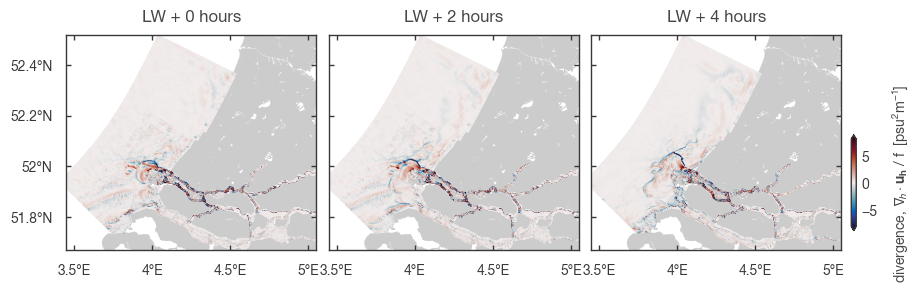

In [80]:
fig, axs = plt.subplots(1,3, FigureClass=GeneralPlot, figsize=(10, 5), sharey=True)
times = [0, 2, 4]

for t, ax in zip(times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
    pc = (div/f).isel(mesh2d_nLayers=35, time=t).ugrid.plot(ax=ax, vmin=-8, vmax=8, cmap=cmo.balance, add_labels=False, add_colorbar=False)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
    ax.set_title(f'LW + {t} hours')

# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0 + 0.02, 0.005, axs[-1].get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"divergence, $\nabla_h \cdot \mathbf{u_h}$ / f  [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
# cb.ax.tick_params(labelsize=9) 
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# add inset ax
# inset_ax = inset_axes(ax, width="30%", height=0.65, loc="upper right", borderpad=1)
# inset_ax.plot(np.arange(0, len(wl.time)), wl)
# inset_ax.scatter(t, wl.isel(time=t))
# inset_ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
# inset_ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
# inset_ax.set_xlabel('hours after LW', fontsize=8, labelpad=0.5)
# inset_ax.set_ylabel('$H$ [m + NAP]', fontsize=8, labelpad=0.5)
# inset_ax.tick_params(
#     axis='both',       # changes apply to the both axes
#     which='both',      # both major and minor ticks are affected
#     left=True,
#     bottom=True,      # ticks along the bottom edge are off
#     top=False,    
#     right=False,      # ticks along the top edge are off
#     labelbottom=True,
#     labelsize=8)

Calculate terms and then rolling average them.

First calculate the tendency from the not tidally averaged `uds`

In [44]:
tendency = sva_obj.tendency

In [34]:
tendency_st = tendency.rolling(dim={"time":12}).mean().mean(dim='time')

Change the `sva_obj` to the tidally averaged `uds`

In [45]:
# uds = uds.rolling(dim={"time":12}).mean()
# sva_obj = constructorSVA(xu.UgridDataset(uds, grids=data_xr.ugrid.grid), data_description)

Calculate the advection, straining, and dissipation on the full uds

In [45]:
straining = sva_obj.straining

/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [ ]:
import matplotlib.colors as mcolors

/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 48.68 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 48.68 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_py/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 48.68 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


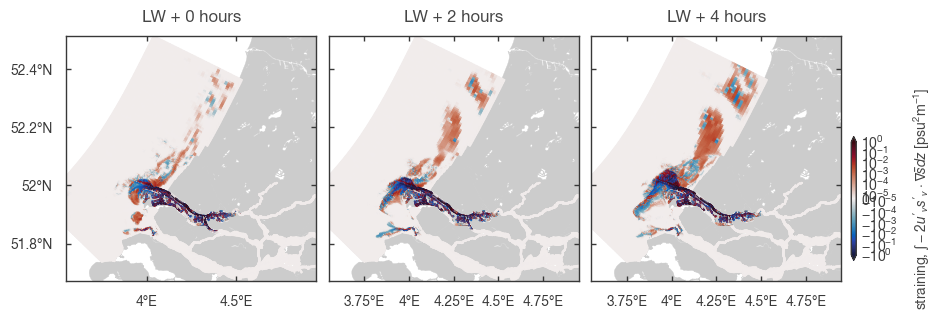

In [39]:
fig, axs = plt.subplots(1,3, FigureClass=GeneralPlot, figsize=(10, 5), sharey=True)
times = [4, 6, 8]

for t, ax in zip(times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
    pc = (straining).isel(time=t).ugrid.plot(ax=ax, cmap=cmo.balance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-5), vmin=-1, vmax=1)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
    ax.set_title(f'LW + {t} hours')

# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0 + 0.02, 0.005, axs[-1].get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"straining, $\int -2u'_{v} s'_{v} \cdot \nabla \bar{s} dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

In [ ]:
# straining = straining.rolling(dim={"time":12}).mean()

In [99]:
dissipation = sva_obj.dissipation

edge-to-face interpolation: 

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Exp

0.43 sec


In [ ]:
dissipation = dissipation.rolling(dim={"time":12}).mean()

In [47]:
advection = sva_obj.advection

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Exp

: 

In [96]:
tendency = sva_obj.tendency

Put all four mechanisms together in a dataset

In [ ]:
sva_obj.ds

In [61]:
import matplotlib.colors as mcolors

In [65]:
from dask_ml.preprocessing import StandardScaler
from dask_ml.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from dask_ml.metrics import silhouette_score

# Load your data using xarray with dask
ds = xr.open_dataset('your_large_dataset.nc', chunks={'time': 10, 'x': 100, 'y': 100})

# Stack the dimensions so that each (time, x, y) becomes a sample
data_vars = ['var1', 'var2', 'var3', 'var4']
stacked = ds[data_vars].to_array().stack(sample=('time', 'x', 'y'))
data = stacked.transpose('sample', 'variable').data

ModuleNotFoundError: No module named 'dask_ml'

In [48]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = straining_comp.ugrid.plot(cmap=cme.variance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-5), vmin=-1, vmax=1)
# pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"straining, $\int -2u'_{v} s'_{v} \cdot \nabla \bar{s} dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
# cb.ax.tick_params(labelsize=9) 

ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-492714' coro=<Client._gather.<locals>.wait() done, defined at /home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:2209> exception=AllExit()>
Traceback (most recent call last):
  File "/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py", line 2218, in wait
    raise AllExit()
distributed.client.AllExit
ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-492715' coro=<Client._gather.<locals>.wait() done, defined at /home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:2209> exception=AllExit()>
Traceback (most recent call last):
  File "/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py", line 2218, in wait
    raise AllExit()
distributed.client.AllExit
INFO:distributed.core:Event loop was unresponsive in Scheduler for 24.53s.

In [38]:
dissipation = sva_obj.dissipation

INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.19s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


edge-to-face interpolation: 0.34 sec


In [39]:
advection = sva_obj.advection

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 13.86 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163

: 

In [73]:
from matplotlib import ticker

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

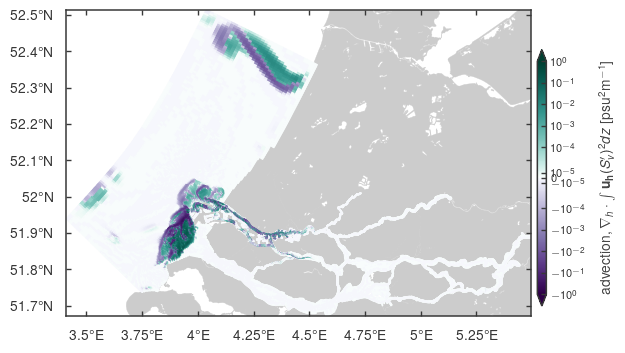

In [79]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = advection.isel(time=2).ugrid.plot(vmin=-1, vmax=1, cmap=cme.variance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-5))

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.1])
# cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"advection, $\nabla_h \cdot \int\mathbf{u_h}(S'_{v})^2 dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
cb.ax.tick_params(labelsize=8)

In [65]:
import cmasher as cmr

In [66]:
cmap_sub = cmr.get_sub_cmap(cme.variance, 0, 0.5)

In [67]:
import matplotlib.colors as mcolors

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

(51.78, 52.28)

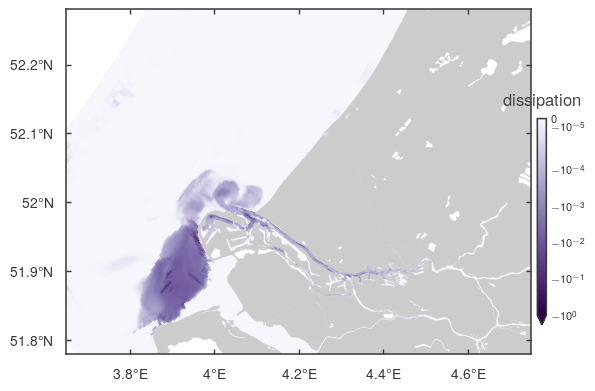

In [83]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
pc = dissipation.isel(time=2).ugrid.plot(vmin=-1, vmax=0, cmap=cmap_sub, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-5), zorder=0)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='min')
tracer_string = r"dissipation"#, $\nabla_h \cdot \int\mathbf{u_h}(S'_{v})^2 dz$ [psu$^2$m$^{-1}$]"
# cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.set_title(f'{tracer_string}')
cb.ax.tick_params(labelsize=8) 
ax.set_xlim(3.65, 4.75)
ax.set_ylim(51.78, 52.28)

In [37]:
# t = '2022/06/23 02:30'
# fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(4,3))
# bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
# pc = (salinity_gradient*1000).isel(mesh2d_nLayers=45).sel(time=t).ugrid.sel(y=slice(51.8, 52.4), x=slice(3.6, 4.5)).ugrid.plot(ax=ax,add_labels=False, add_colorbar=False, vmax=5, zorder=0)

# # add colorbar
# cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.03, ax.get_position().height - 0.2])
# cax.tick_params(axis=u'both', which=u'both', length=0)

# # cbar limits + others
# ax.set_ylim(51.8, 52.35)
# ax.set_xlim(3.65, 4.45)
# cb = plt.colorbar(pc, cax=cax, extend='max')
# tracer_string = r'$|\nabla_h s|$ [psu/km]'
# cb.set_label(f'{tracer_string}', labelpad=10, fontsize=8)
# cb.ax.tick_params(labelsize=6) 
# ax.set_title(f'{t}, LW')
# # plt.savefig('fronts_LW.png', transparent=True)

In [66]:
import matplotlib as mpl

In [36]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

In [120]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='EPSG:28992', zorder=0)

pc=(div/f).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r'$\nabla\cdot\mathbf{u}$'
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=9) 

In [ ]:
gradient = sva_obj.compute_gradient_on_face(sva_obj.tracer)

In [47]:
salinity_gradient = np.sqrt(gradient.isel({dimn_cart:0})**2 + gradient.isel({dimn_cart:1})**2).where(~bool_drycells)

<xarray.Dataset>
Dimensions:                      (time: 13, mesh2d_nNodes: 133336,
                                  mesh2d_nFaces: 126438, mesh2d_nLayers: 36,
                                  mesh2d_nInterfaces: 37, Two: 2,
                                  mesh2d_nEdges: 259786,
                                  mesh2d_nCartesian_coords: 2)
Coordinates:
  * time                         (time) datetime64[ns] 2022-01-01T12:00:00 .....
    mesh2d_node_x                (mesh2d_nNodes) float64 4.252 4.253 ... 4.459
    mesh2d_node_y                (mesh2d_nNodes) float64 51.79 51.79 ... 51.89
    mesh2d_face_x                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_face_y                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_zcc          (time, mesh2d_nFaces, mesh2d_nLayers) float32 dask.array<chunksize=(1, 1315, 36), meta=np.ndarray>
    mesh2d_flowelem_zw           (time, mesh2d_nFaces, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 1315, 37), meta=np.ndarray>
    mesh2d_edge_x                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
    mesh2d_edge_y                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
  * mesh2d_nFaces                (mesh2d_nFaces) int64 0 1 2 ... 126436 126437
  * mesh2d_nEdges                (mesh2d_nEdges) int64 0 1 2 ... 259784 259785
  * mesh2d_nNodes                (mesh2d_nNodes) int64 0 1 2 ... 133334 133335
Dimensions without coordinates: mesh2d_nLayers, mesh2d_nInterfaces, Two,
                                mesh2d_nCartesian_coords
Data variables: (12/46)
    projected_coordinate_system  int32 ...
    timestep                     (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    mesh2d_node_z                (mesh2d_nNodes) float64 dask.array<chunksize=(1394,), meta=np.ndarray>
    mesh2d_bldepth               (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_ba           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_bl           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    ...                           ...
    mesh2d_turkin1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_vicwwu                (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_tureps1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_cftrt                 (time, mesh2d_nEdges) float32 dask.array<chunksize=(1, 2708), meta=np.ndarray>
    mesh2d_dicwwu                (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_unvs                  (mesh2d_nEdges, mesh2d_nCartesian_coords) float64 ...
Attributes:
    institution:               Deltares
    references:                https://www.deltares.nl
    source:                    D-Flow FM 1.2.184.4a31aea51d1d200d4eb2f3262c80...
    history:                   Created on 2024-05-02T16:15:43+0200, D-Flow FM
    date_created:              2024-05-02T16:15:43+0200
    date_modified:             2024-05-02T16:15:43+0200
    Conventions:               CF-1.8 UGRID-1.0 Deltares-0.10 ACDD-1.3
    uuid:                      203ecdd4-9b57-45fc-a456-b02b9058b80f
    time_coverage_start:       2022-01-01T12:00:00+00:00
    time_coverage_end:         2022-01-02T12:00:00+00:00
    time_coverage_duration:    P0000-00-01T00:00:00
    time_coverage_resolution:  P0000-00-00T02:00:00

INFO:distributed.utils_perf:full garbage collection released 11.25 MiB from 135046 reference cycles (threshold: 9.54 MiB)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 39.34 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.24s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


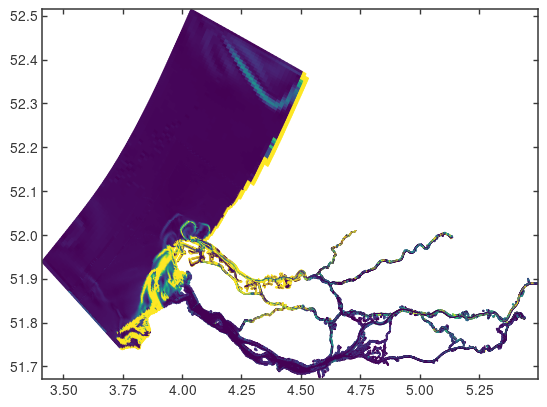

In [71]:
(salinity_gradient*1000).where(uds['mesh2d_flowelem_bl'] < -.5, np.nan).isel(mesh2d_nLayers=35, time=2).ugrid.plot(add_labels=False, add_colorbar=False, vmax=5, zorder=0)

In [39]:
valid_files = validate_input(r'/projects/0/einf1300/saltis-wp3-1/D_Analysis/01_Simulations/05_RMD_2019/D02_red_ts/*')

/scratch-local/mgeraeds/ipykernel_833508/2962624512.py:23: UserWarning: The file D02AU_red_delayed_1776.nc seems to be corrupted. Check your inputs.
  warnings.warn(f'The file {file_name} seems to be corrupted. Check your inputs.', UserWarning)
/scratch-local/mgeraeds/ipykernel_833508/2962624512.py:23: UserWarning: The file D02AU_red_delayed_1210.nc seems to be corrupted. Check your inputs.
  warnings.warn(f'The file {file_name} seems to be corrupted. Check your inputs.', UserWarning)
/scratch-local/mgeraeds/ipykernel_833508/2962624512.py:23: UserWarning: The file D02AU_red_delayed_523.nc seems to be corrupted. Check your inputs.
  warnings.warn(f'The file {file_name} seems to be corrupted. Check your inputs.', UserWarning)
/scratch-local/mgeraeds/ipykernel_833508/2962624512.py:23: UserWarning: The file D02AU_red_delayed_660.nc seems to be corrupted. Check your inputs.
  warnings.warn(f'The file {file_name} seems to be corrupted. Check your inputs.', UserWarning)
/scratch-local/mgeraed

There are corrupted files. These will be taken out of the file list for the next tests.
